In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= Config =========
csv_path  = "/Users/shiyalin/Desktop/patient_features_final_with_past.csv"  
unit_col  = "encounter_medical_service"
start_col = "encounter_start_dt"
end_col   = "encounter_end_dt"

# Departments to keep
keep_units = ["Nursing - medical / surgical", "Emergency medicine"]

# Fixed 118-day window
window_start = pd.Timestamp("2022-11-01")
window_days  = 118
window_end   = window_start + pd.Timedelta(days=window_days - 1)  

# Output file (single CSV)
out_csv = "./encounter_timeseries_pivot_selected_118d.csv"  

# ========= Helpers =========
def to_utc_naive(series):
    """
    Parse to datetime with UTC timezone, then drop timezone to get UTC-naive.
    This prevents tz-aware vs tz-naive comparison errors.
    """
    dt = pd.to_datetime(series, errors="coerce", utc=True)  # tz-aware (UTC)
    return dt.dt.tz_localize(None)                          # drop tz → naive

# ========= 1) Load & basic filtering =========
df = pd.read_csv(csv_path, low_memory=False)

missing = [c for c in [unit_col, start_col, end_col] if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

# Keep only the two departments of interest
df = df[df[unit_col].isin(keep_units)].copy()

# ========= 2) Parse datetimes (UTC-naive) & normalize to dates =========
df["_start_dt"] = to_utc_naive(df[start_col])
df["_end_dt"]   = to_utc_naive(df[end_col])
df = df.dropna(subset=["_start_dt", "_end_dt"]).copy()

# If end < start (dirty records), swap them
swap = df["_end_dt"] < df["_start_dt"]
if swap.any():
    tmp = df.loc[swap, "_start_dt"].copy()
    df.loc[swap, "_start_dt"] = df.loc[swap, "_end_dt"]
    df.loc[swap, "_end_dt"]   = tmp

# Normalize to pure dates (strip time-of-day)
df["_start_date"] = df["_start_dt"].dt.normalize()
df["_end_date"]   = df["_end_dt"].dt.normalize()

# ========= 3) Clip encounters to the fixed window =========
# Clip to [window_start, window_end]; drop encounters with no overlap after clipping.
df["_start_clip"] = df["_start_date"].where(df["_start_date"] >= window_start, window_start)
df["_end_clip"]   = df["_end_date"]  .where(df["_end_date"]   <= window_end,   window_end)
df = df[df["_start_clip"] <= df["_end_clip"]].copy()

In [2]:
# ========= 4) Build event table (per department) =========
# +1 at start_clip (enter), -1 at end_clip + 1 day (leave takes effect next day)
starts = (
    df[[unit_col, "_start_clip"]]
    .assign(delta=1)
    .rename(columns={"_start_clip": "date"})
)
ends = (
    df[[unit_col, "_end_clip"]]
    .assign(date=lambda x: x["_end_clip"] + pd.Timedelta(days=1), delta=-1)
    [[unit_col, "date", "delta"]]
)
events = pd.concat([starts, ends], ignore_index=True)

# Keep only event dates within [window_start, window_end+1]
events = events[(events["date"] >= window_start) & (events["date"] <= window_end + pd.Timedelta(days=1))].copy()

# Aggregate net delta per (department, date)
events_agg = events.groupby([unit_col, "date"], as_index=False)["delta"].sum()

# ========= 5) Construct daily counts per department within the window =========
def build_unit_timeseries(group):
    """
    For a single department:
    - Reindex event deltas over [window_start, window_end+1]
    - Cumulative sum to get daily counts
    - Then trim back to [window_start, window_end]
    """
    g = group.sort_values("date").copy()
    full_idx = pd.date_range(window_start, window_end + pd.Timedelta(days=1), freq="D")
    g_full = (
        g.set_index("date")
         .reindex(full_idx)
         .rename_axis("date")
         .assign(**{unit_col: g[unit_col].iloc[0]})
         .fillna({"delta": 0})
         .reset_index()
    )
    g_full["count"] = g_full["delta"].cumsum()
    g_full = g_full[(g_full["date"] >= window_start) & (g_full["date"] <= window_end)].copy()
    return g_full[[unit_col, "date", "count"]]

timeseries = (
    events_agg.groupby(unit_col, group_keys=False)
    .apply(build_unit_timeseries)
    .reset_index(drop=True)
)

/var/folders/s2/ly676psd1glf19n7hggl68400000gn/T/ipykernel_15654/2948235910.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  events_agg.groupby(unit_col, group_keys=False)


In [3]:
# ========= 6) Pivot to one 118-day table (date x department) =========
pivot = (
    timeseries
    .pivot(index="date", columns=unit_col, values="count")
    .sort_index()
)

# Make sure columns appear in the desired order
pivot = pivot.reindex(columns=keep_units)
pivot.to_csv(out_csv)
print("Saved 118-day pivot CSV to:", out_csv)
print("\nPivot head (118-day window):")
print(pivot.head(10))

Saved 118-day pivot CSV to: ./encounter_timeseries_pivot_selected_118d.csv

Pivot head (118-day window):
encounter_medical_service  Nursing - medical / surgical  Emergency medicine
date                                                                       
2022-11-01                                           68                  29
2022-11-02                                          134                  35
2022-11-03                                          213                  45
2022-11-04                                          262                  32
2022-11-05                                          323                  41
2022-11-06                                          368                  41
2022-11-07                                          404                  25
2022-11-08                                          444                  23
2022-11-09                                          500                  42
2022-11-10                                          541    

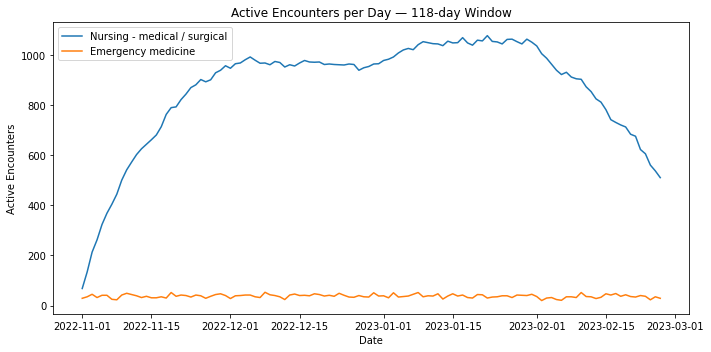

In [4]:
# Show a quick comparison plot 
plt.figure(figsize=(10, 5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=str(col))
plt.title("Active Encounters per Day — 118-day Window")
plt.xlabel("Date")
plt.ylabel("Active Encounters")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
from math import sqrt
import warnings
warnings.filterwarnings("ignore")

import matplotlib.dates as mdates
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ---------------- Global configuration ----------------
TEST_DAYS = 14        # length of the holdout window
SEASON    = 7         # weekly seasonality for daily series

# ---------------- Metrics (RMSE, MAPE%, MAE) ----------------
def rmse(y_true, y_pred):
    """Root Mean Squared Error."""
    return float(sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred))**2)))

def mae(y_true, y_pred):
    """Mean Absolute Error."""
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def mape(y_true, y_pred, eps=1e-8):
    """MAPE% with zero guard: ignore points where y_true == 0."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    mask = np.abs(y_true) > eps
    if not mask.any():
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def eval_block(y_true, yhat_series):
    """Compute RMSE / MAPE% / MAE given a forecast Series (point forecast only)."""
    y_pred = np.asarray(pd.Series(yhat_series).values)
    return {"RMSE": rmse(y_true, y_pred),
            "MAPE%": mape(y_true, y_pred),
            "MAE": mae(y_true, y_pred)}

# ---------------- Data split ----------------
def split_tail_as_test(y, test_days=TEST_DAYS):
    y = y.asfreq("D").fillna(0).astype(float)
    assert len(y) > test_days, "Series must be longer than test horizon."
    return y.iloc[:-test_days], y.iloc[-test_days:]

# ---------------- Plot helper (denser time ticks) ----------------
def plot_backtest(train, test, yhat, title, tick="weekly"):
    fig, ax = plt.subplots(figsize=(9, 5))
    train.plot(ax=ax, label="Train")
    test.plot(ax=ax, label="Test", linestyle="--")
    yhat.plot(ax=ax, label="Forecast", linewidth=2)

    # Configure x-axis ticks
    if tick == "daily":
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    elif isinstance(tick, int) and tick > 0:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=tick))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    else:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Encounters")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

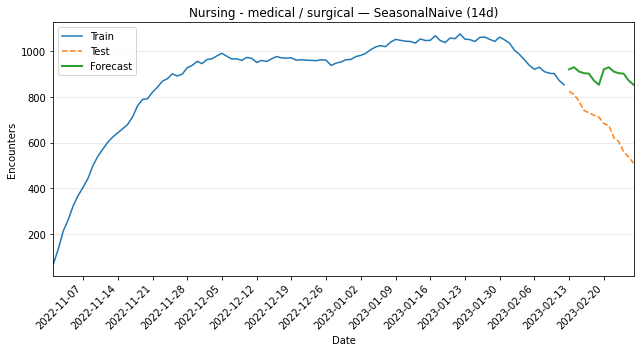

SeasonalNaive metrics:
          RMSE      MAPE%         MAE
0  236.195591  34.913024  219.642857


In [6]:
# Model 1 — Seasonal Naive 
def seasonal_naive_forecast(y_train, h, season=SEASON):
    """
    Seasonal naive: yhat_{t+h} = y_{t+h-m}
    Uses the last `season` observations to repeat forward.
    If training length < season, it gracefully reduces season length.
    """
    y_train = y_train.asfreq("D")
    eff_season = int(min(season, max(1, len(y_train))))
    last_block = y_train.iloc[-eff_season:]
    reps = int(np.ceil(h / eff_season))
    vals = np.tile(last_block.values, reps)[:h]
    idx = pd.date_range(y_train.index[-1] + pd.Timedelta(days=1), periods=h, freq="D")
    return pd.Series(vals, index=idx, name="mean")

def run_sn_for_unit(pivot, unit, tick="weekly"):
    """
    Run Seasonal Naive for one unit; plot backtest and print metrics.
    """
    y = pivot[unit].asfreq("D").fillna(0)
    y_tr, y_te = split_tail_as_test(y, TEST_DAYS)
    h = len(y_te)
    yhat = seasonal_naive_forecast(y_tr, h=h, season=SEASON)
    metrics = eval_block(y_te.values, yhat)
    plot_backtest(y_tr, y_te, yhat, f"{unit} — SeasonalNaive ({h}d)", tick=tick)
    print("SeasonalNaive metrics:\n", pd.DataFrame([metrics])[["RMSE", "MAPE%", "MAE"]])
    return {"train": y_tr, "test": y_te, "yhat": yhat, "metrics": metrics}

unit1 = "Nursing - medical / surgical"
sn_res1  = run_sn_for_unit(pivot, unit1, tick="weekly")

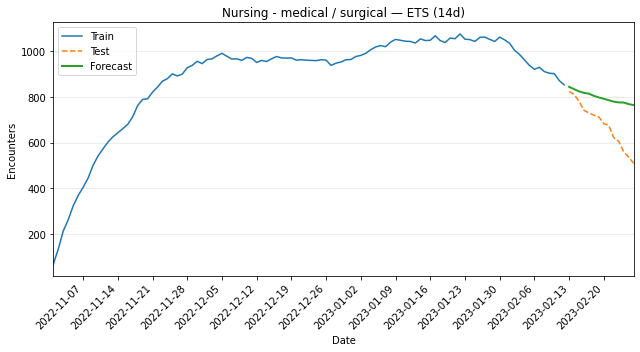

ETS best spec: {'error': 'add', 'trend': 'add', 'seasonal': 'add', 'damped_trend': True} AIC: 838.8642198694611
ETS metrics:
          RMSE      MAPE%         MAE
0  139.696063  19.566591  119.100615


In [7]:
# Model 2 — ETS 
def _ets_point_from_fit(fit, h, last_index):
    idx = pd.date_range(last_index + pd.Timedelta(days=1), periods=h, freq="D")

    # 1) get_forecast if available
    if hasattr(fit, "get_forecast"):
        try:
            pm = fit.get_forecast(steps=h).predicted_mean
            # ensure index matches expected daily horizon
            pm = pd.Series(np.asarray(pm), index=idx, name="mean")
            return pm
        except Exception:
            pass

    # 2) forecast(h) if available
    if hasattr(fit, "forecast"):
        try:
            vals = fit.forecast(h)  # array-like
            return pd.Series(np.asarray(vals), index=idx, name="mean")
        except Exception:
            pass

    # 3) predict by integer positions: [len, len+h-1]
    try:
        start = fit.model.endog.shape[0]  # first out-of-sample step
        end   = start + h - 1
        vals  = fit.predict(start=start, end=end)
        return pd.Series(np.asarray(vals), index=idx, name="mean")
    except Exception as e:
        raise RuntimeError(f"ETS forecast compatibility failed: {e}")

def ets_auto_point(y_train, h, season=SEASON):
    """
    Try a small set of ETS specs and choose the best by AIC, then produce point forecasts.
    Specs: (A,N,A), (A,A,A), (A,Adamped,A)
    """
    specs = [
        dict(error="add", trend=None,  seasonal="add", damped_trend=False),
        dict(error="add", trend="add", seasonal="add", damped_trend=False),
        dict(error="add", trend="add", seasonal="add", damped_trend=True ),
    ]
    best = None
    for sp in specs:
        try:
            mod = ETSModel(y_train.astype(float),
                           seasonal_periods=season,
                           initialization_method="estimated",
                           **sp)
            fit = mod.fit(disp=False)
            if (best is None) or (fit.aic < best["aic"]):
                best = {"fit": fit, "aic": float(fit.aic), "spec": sp}
        except Exception:
            pass
    if best is None:
        raise RuntimeError("ETS auto selection failed on all candidate specs.")
    # Point forecast with compatibility shim
    yhat = _ets_point_from_fit(best["fit"], h=h, last_index=y_train.index[-1])
    return yhat, best

def run_ets_for_unit(pivot, unit, tick="weekly"):
    """
    Run state-space ETS for one unit; plot backtest and print metrics/spec.
    """
    y = pivot[unit].asfreq("D").fillna(0)
    y_tr, y_te = split_tail_as_test(y, TEST_DAYS)
    h = len(y_te)
    yhat, best = ets_auto_point(y_tr, h=h, season=SEASON)
    metrics = eval_block(y_te.values, yhat)
    plot_backtest(y_tr, y_te, yhat, f"{unit} — ETS ({h}d)", tick=tick)
    print("ETS best spec:", best["spec"], "AIC:", best["aic"])
    print("ETS metrics:\n", pd.DataFrame([metrics])[["RMSE", "MAPE%", "MAE"]])
    return {"train": y_tr, "test": y_te, "yhat": yhat, "metrics": metrics, "spec": best["spec"]}

ets_res1 = run_ets_for_unit(pivot, unit1, tick="weekly")

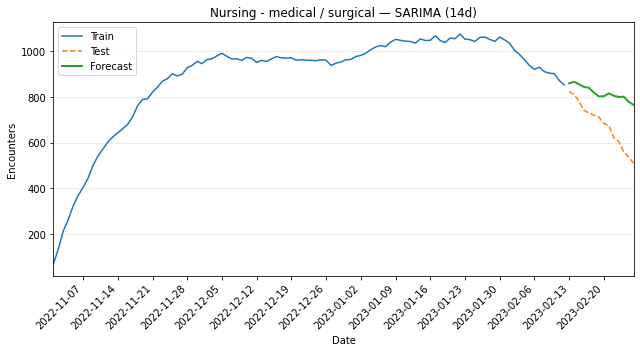

SARIMA metrics:
          RMSE      MAPE%         MAE
0  155.404088  22.450445  138.902573


In [8]:
# Model 3 — SARIMA 
def sarima_point(y_train, h, order=(1,0,0), seasonal_order=(1,1,0,SEASON)):
    model = SARIMAX(y_train.astype(float),
                    order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    fc = fit.get_forecast(steps=h)
    pm = fc.predicted_mean
    idx = pd.date_range(y_train.index[-1] + pd.Timedelta(days=1), periods=h, freq="D")
    yhat = pd.Series(np.asarray(pm), index=idx, name="mean")
    return yhat, fit

def run_sarima_for_unit(pivot, unit, order=(1,0,0), seasonal_order=(1,1,0,SEASON), tick="weekly"):
    """
    Run SARIMA for one unit; plot backtest and print metrics.
    """
    y = pivot[unit].asfreq("D").fillna(0)
    y_tr, y_te = split_tail_as_test(y, TEST_DAYS)
    h = len(y_te)
    yhat, fit = sarima_point(y_tr, h=h, order=order, seasonal_order=seasonal_order)
    metrics = eval_block(y_te.values, yhat)
    plot_backtest(y_tr, y_te, yhat, f"{unit} — SARIMA ({h}d)", tick=tick)
    print("SARIMA metrics:\n", pd.DataFrame([metrics])[["RMSE", "MAPE%", "MAE"]])
    return {"train": y_tr, "test": y_te, "yhat": yhat, "metrics": metrics,
            "order": order, "sorder": seasonal_order}

sa_res1  = run_sarima_for_unit(pivot, unit1, tick="weekly")

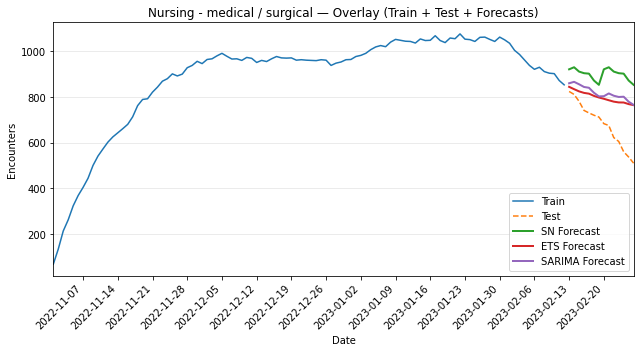


Comparison (sorted by RMSE):
         model       RMSE     MAPE%        MAE
          ETS 139.696063 19.566591 119.100615
       SARIMA 155.404088 22.450445 138.902573
SeasonalNaive 236.195591 34.913024 219.642857


In [9]:
def overlay_and_compare_for_unit(pivot, unit, sn_res, ets_res, sa_res, tick="weekly"):
    # Reuse the same split used in the three runs
    y_tr = sn_res["train"]
    y_te = sn_res["test"]

    import matplotlib.dates as mdates
    fig, ax = plt.subplots(figsize=(9,5))

    # train & test (same for all models)
    y_tr.plot(ax=ax, label="Train")
    y_te.plot(ax=ax, label="Test", linestyle="--")

    # three forecasts (point forecasts)
    sn_res["yhat"].plot(ax=ax, label="SN Forecast", linewidth=2)
    ets_res["yhat"].plot(ax=ax, label="ETS Forecast", linewidth=2)
    sa_res["yhat"].plot(ax=ax, label="SARIMA Forecast", linewidth=2)

    # ticks
    if tick == "daily":
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    elif isinstance(tick, int) and tick > 0:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=tick))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    else:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title(f"{unit} — Overlay (Train + Test + Forecasts)")
    ax.set_xlabel("Date"); ax.set_ylabel("Encounters")
    ax.legend(); ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

    # metrics table 
    comp = pd.DataFrame([
        {"model": "SeasonalNaive", **sn_res["metrics"]},
        {"model": "ETS",           **ets_res["metrics"]},
        {"model": "SARIMA",        **sa_res["metrics"]},
    ])[["model","RMSE","MAPE%","MAE"]].sort_values("RMSE")
    print("\nComparison (sorted by RMSE):\n", comp.to_string(index=False))
    return comp

comp_df1 = overlay_and_compare_for_unit(pivot, unit1, sn_res1, ets_res1, sa_res1, tick="weekly")

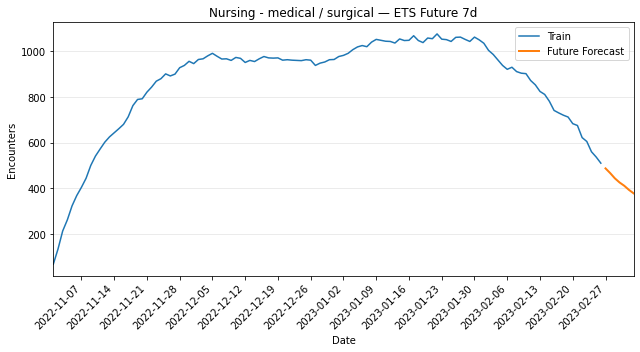

In [10]:
# ==== Refit ETS on full history with chosen spec, then forecast future ====
def ets_refit_and_future_point(y_full, best_spec, h, season=SEASON):
    from statsmodels.tsa.exponential_smoothing.ets import ETSModel
    y_full = y_full.asfreq("D").fillna(0).astype(float)
    mod = ETSModel(y_full, seasonal_periods=season, initialization_method="estimated", **best_spec)
    fit = mod.fit(disp=False)

    last_index = y_full.index[-1]
    idx = pd.date_range(last_index + pd.Timedelta(days=1), periods=h, freq="D")

    if hasattr(fit, "get_forecast"):
        try:
            pm = fit.get_forecast(steps=h).predicted_mean
            return pd.Series(np.asarray(pm), index=idx, name="mean")
        except Exception:
            pass
    if hasattr(fit, "forecast"):
        try:
            vals = fit.forecast(h)
            return pd.Series(np.asarray(vals), index=idx, name="mean")
        except Exception:
            pass
    start = fit.model.endog.shape[0]
    end   = start + h - 1
    vals  = fit.predict(start=start, end=end)
    return pd.Series(np.asarray(vals), index=idx, name="mean")

# ==== Plot train + future forecast, with dense date ticks ====
def plot_train_and_future(y_full, yhat_future, title, tick="weekly"):
    """Plot full training history and future point forecasts (no saving)."""
    import matplotlib.dates as mdates
    fig, ax = plt.subplots(figsize=(9,5))
    y_full.plot(ax=ax, label="Train")
    yhat_future.plot(ax=ax, label="Future Forecast", linewidth=2)

    # ticks: 'daily' / 'weekly' / int (every N days)
    if tick == "daily":
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    elif isinstance(tick, int) and tick > 0:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=tick))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    else:  # weekly (Mondays)
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title(title); ax.set_xlabel("Date"); ax.set_ylabel("Encounters")
    ax.legend(); ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

best_spec1   = ets_res1["spec"]
y_full_1     = pivot[unit1].asfreq("D").fillna(0)
yhat_future1 = ets_refit_and_future_point(y_full_1, best_spec1, h=7, season=SEASON)
plot_train_and_future(y_full_1, yhat_future1, f"{unit1} — ETS Future 7d", tick="weekly")

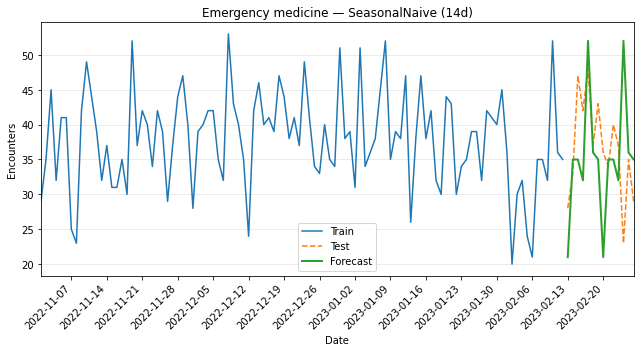

SeasonalNaive metrics:
         RMSE      MAPE%       MAE
0  10.460811  23.592703  7.571429


In [11]:
unit2 = "Emergency medicine"
sn_res2  = run_sn_for_unit(pivot, unit2, tick="weekly")

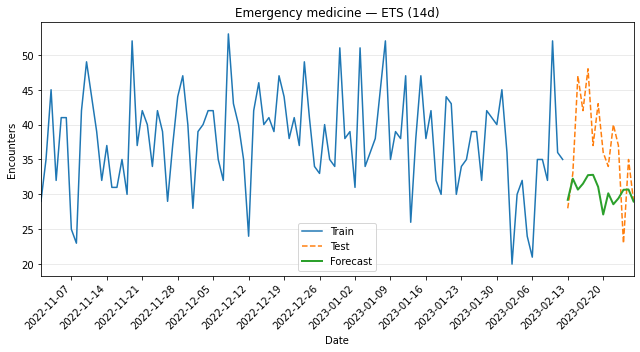

ETS best spec: {'error': 'add', 'trend': 'add', 'seasonal': 'add', 'damped_trend': False} AIC: 714.634427891535
ETS metrics:
        RMSE      MAPE%       MAE
0  8.980075  19.128096  7.416941


In [12]:
ets_res2 = run_ets_for_unit(pivot, unit2, tick="weekly")

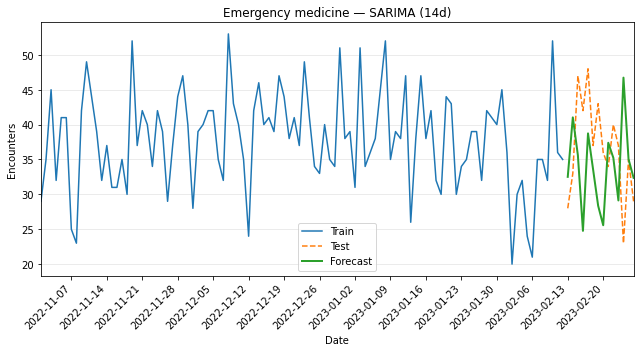

SARIMA metrics:
         RMSE      MAPE%       MAE
0  10.699303  25.379132  8.719437


In [13]:
sa_res2  = run_sarima_for_unit(pivot, unit2, tick="weekly")

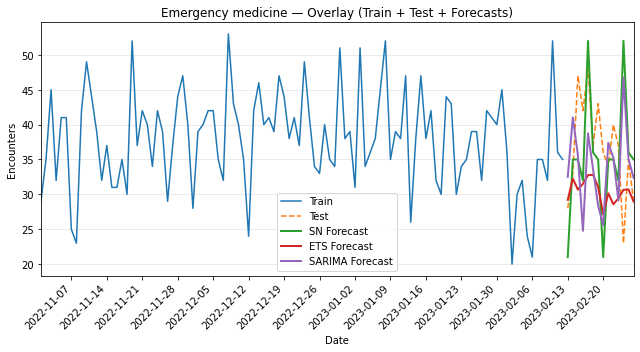


Comparison (sorted by RMSE):
         model      RMSE     MAPE%      MAE
          ETS  8.980075 19.128096 7.416941
SeasonalNaive 10.460811 23.592703 7.571429
       SARIMA 10.699303 25.379132 8.719437


In [14]:
comp_df2 = overlay_and_compare_for_unit(pivot, unit2, sn_res2, ets_res2, sa_res2, tick="weekly")

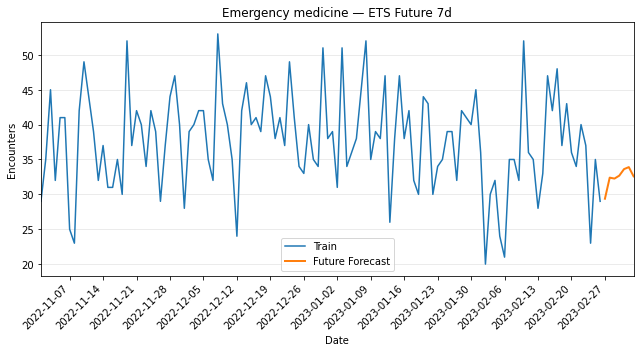

In [15]:
best_spec2   = ets_res2["spec"]
y_full_2     = pivot[unit2].asfreq("D").fillna(0)
yhat_future2 = ets_refit_and_future_point(y_full_2, best_spec2, h=7, season=SEASON)
plot_train_and_future(y_full_2, yhat_future2, f"{unit2} — ETS Future 7d", tick="weekly")